# EarlyGate vs gold — **resultado fijado (300 casos)**

Este notebook **no llama a la API**: lee la corrida ya guardada en [`docs/expo_early_gate_eval_300/`](../docs/expo_early_gate_eval_300/README.md) (`predictions.csv`, `summary.json`, figuras).

Incluye **tablas de métricas** y **gráficas** alineadas al baseline (F1, κ, matriz de confusión). Para volver a evaluar con LLM: `python scripts/eval_early_gate_corpus.py` y copiar la nueva salida a `docs/expo_early_gate_eval_300/` si se desea actualizar la expo.

In [1]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "docs" / "expo_early_gate_eval_300" / "predictions.csv").is_file():
            return p
    raise FileNotFoundError(
        "No se encontró docs/expo_early_gate_eval_300/predictions.csv (ejecute desde la raíz del repo)."
    )


REPO_ROOT = find_repo_root()
ART = REPO_ROOT / "docs" / "expo_early_gate_eval_300"

df_src = pd.read_csv(ART / "predictions.csv")
with (ART / "summary.json").open(encoding="utf-8") as f:
    summary_run = json.load(f)

labels = ["play", "pausa", "stop"]
y_true = df_src["gold_mode"].astype(str).tolist()
y_pred = df_src["predicted_mode"].astype(str).tolist()
elapsed = summary_run.get("elapsed_sec", float("nan"))
n_s = len(df_src)

print("Artefactos:", ART)
print("Muestras:", n_s, "| tiempo corrida original (s):", elapsed)
print("Resumen accuracy / F1-macro / κ:", summary_run["metrics"])

Artefactos: C:\Users\jlpy\Documents\UniMaestria\4Semestre\Proyecto de Investigacion 2\Tesis\docs\expo_early_gate_eval_300
Muestras: 300 | tiempo corrida original (s): 696.64
Resumen accuracy / F1-macro / κ: {'accuracy': 0.79, 'f1_macro': 0.7668674197219061, 'cohen_kappa': 0.685, 'f1_per_class': {'play': 0.7604562737642585, 'pausa': 0.5401459854014599, 'stop': 1.0}}


In [2]:
acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
f1_per = f1_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
kappa = cohen_kappa_score(y_true, y_pred, labels=labels)
cm = confusion_matrix(y_true, y_pred, labels=labels)

prec, rec, f1_prf, support_vec = precision_recall_fscore_support(
    y_true, y_pred, labels=labels, zero_division=0
)

display(
    pd.DataFrame(
        {"métrica": ["accuracy", "f1_macro", "cohen_kappa"], "valor": [acc, f1_macro, kappa]}
    )
)

df_class = pd.DataFrame(
    {
        "clase": labels,
        "precision": prec,
        "recall": rec,
        "f1": f1_prf,
        "support": support_vec,
    }
)
display(df_class)

by_src = (
    df_src.groupby("source", dropna=False)
    .agg(n=("id", "count"), correct=("match", "sum"))
    .reset_index()
)
by_src["accuracy"] = by_src["correct"] / by_src["n"]
display(by_src.sort_values("n", ascending=False))

print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

,métrica,valor
0,accuracy,0.790000
1,f1_macro,0.766867
2,cohen_kappa,0.685000


,clase,precision,recall,f1,support
0,play,0.613497,1.00,0.760456,100
1,pausa,1.000000,0.37,0.540146,100
2,stop,1.000000,1.00,1.000000,100


,source,n,correct,accuracy
1,llm,298,235,0.788591
0,lexical,1,1,1.000000
2,llm_fallback,1,1,1.000000


              precision    recall  f1-score   support

        play       0.61      1.00      0.76       100
       pausa       1.00      0.37      0.54       100
        stop       1.00      1.00      1.00       100

    accuracy                           0.79       300
   macro avg       0.87      0.79      0.77       300
weighted avg       0.87      0.79      0.77       300



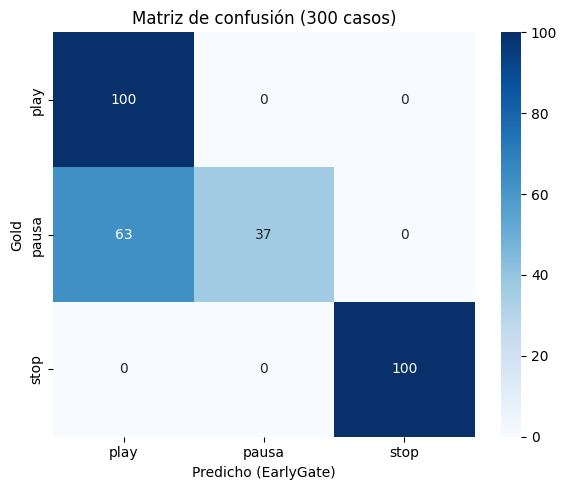

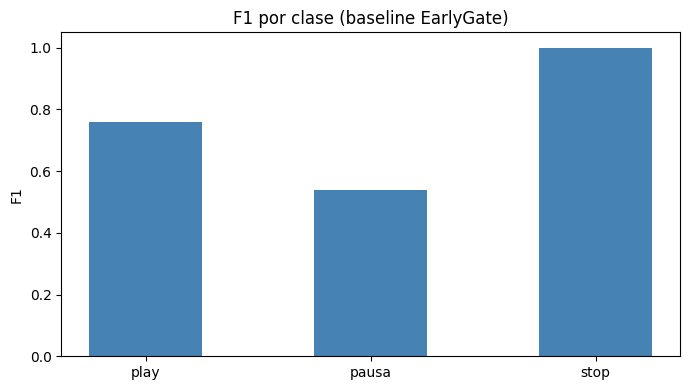

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
)
ax.set_xlabel("Predicho (EarlyGate)")
ax.set_ylabel("Gold")
ax.set_title("Matriz de confusión (300 casos)")
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 4))
x = np.arange(len(labels))
ax2.bar(x, [f1_per[i] for i in range(3)], width=0.5, color="steelblue")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("F1")
ax2.set_title("F1 por clase (baseline EarlyGate)")
plt.tight_layout()
plt.show()

# Las mismas figuras están guardadas en docs/expo_early_gate_eval_300/*.png

In [4]:
df_err = df_src[~df_src["match"]][
    ["id", "gold_mode", "predicted_mode", "source", "confidence"]
].head(25)
display(df_err)

,id,gold_mode,predicted_mode,source,confidence
100,CRT-PAUSE-001,pausa,play,llm,0.95
102,CRT-PAUSE-003,pausa,play,llm,0.95
103,CRT-PAUSE-004,pausa,play,llm,0.95
104,CRT-PAUSE-005,pausa,play,llm,0.90
105,CRT-PAUSE-006,pausa,play,llm,0.95
106,CRT-PAUSE-007,pausa,play,llm,0.95
111,CRT-PAUSE-012,pausa,play,llm,0.95
112,CRT-PAUSE-013,pausa,play,llm,0.95
113,CRT-PAUSE-014,pausa,play,llm,0.90
114,CRT-PAUSE-015,pausa,play,llm,0.95
